# Feature Engineering

In this notebook, we create new features from the existing dataset to enhance the predictive performance of machine learning models.

The engineered features are designed based on domain knowledge and clinical relevance rather than arbitrary mathematical transformations.

Objectives:

- Create meaningful features from existing variables.
- Improve model interpretability.
- Preserve information while reducing feature complexity.
- Save the engineered dataset for the next stage (Feature Selection).

## importing libraries ##

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Display settings
pd.set_option("display.max_columns", None)

## Load Data Set ##

In [6]:
# Load preprocessed dataset
df = pd.read_csv("../data/processed/preprocessing.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (101766, 43)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,5,6,25,1,1,41,0,1,0,0,0,250.83,NaN,NaN,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,15,1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,1
2,AfricanAmerican,Female,25,1,1,7,2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,35,1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,45,1,1,7,1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,0


## Copy Dataset ##

In [7]:
engineered_df = df.copy()

print("Dataset copied successfully.")

Dataset copied successfully.


## Feature 1 ## 
# : total visits #

In [9]:
engineered_df["total_visits"] = (
    engineered_df["number_outpatient"] +
    engineered_df["number_emergency"] +
    engineered_df["number_inpatient"]
)

engineered_df["total_visits"].describe()

count    101766.000000
mean          1.202759
std           2.291781
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          80.000000
Name: total_visits, dtype: float64

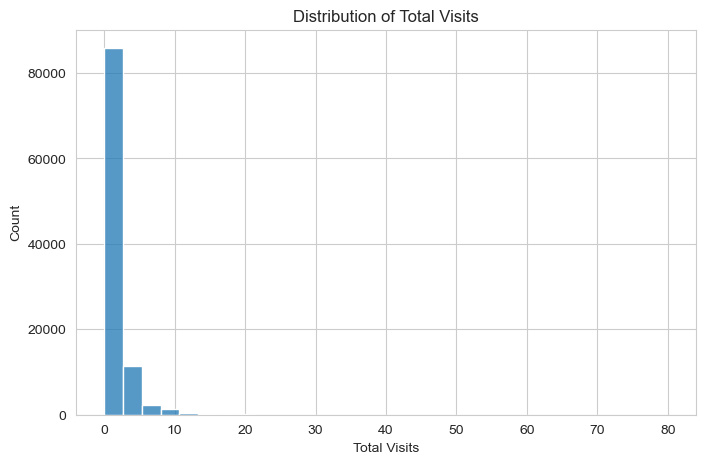

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=engineered_df,
    x="total_visits",
    bins=30
)

plt.title("Distribution of Total Visits")
plt.xlabel("Total Visits")
plt.ylabel("Count")

plt.show()

## Identify Medication Features ##

In [11]:
# List of non-medication categorical columns
non_medication_columns = [
    "race",
    "gender",
    "age",
    "weight",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "diag_1",
    "diag_2",
    "diag_3",
    "payer_code",
    "medical_specialty",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
    "readmitted"
]

# Medication columns are categorical columns excluding the above
medication_columns = [
    col for col in engineered_df.columns
    if engineered_df[col].dtype == "object"
    and col not in non_medication_columns
]

print(f"Number of medication features: {len(medication_columns)}")
print(medication_columns)

Number of medication features: 23
['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


## Active Medication Count ##

In [12]:
engineered_df["active_medications"] = (
    engineered_df[medication_columns]
    .ne("No")
    .sum(axis=1)
)

engineered_df["active_medications"].describe()

count    101766.000000
mean          1.179706
std           0.920190
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: active_medications, dtype: float64

## Changed Medication Count ##

In [13]:
engineered_df["changed_medications"] = (
    engineered_df[medication_columns]
    .isin(["Up", "Down"])
    .sum(axis=1)
)

engineered_df["changed_medications"].describe()

count    101766.000000
mean          0.287444
std           0.487526
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           4.000000
Name: changed_medications, dtype: float64

## Reslt ##

In [14]:
engineered_df[
    [
        "active_medications",
        "changed_medications"
    ]
].head(10)

,active_medications,changed_medications
0,0,0
1,1,1
2,1,0
3,1,1
4,2,0
5,1,0
6,3,0
7,1,0
8,2,0
9,2,0


## Visualization ##

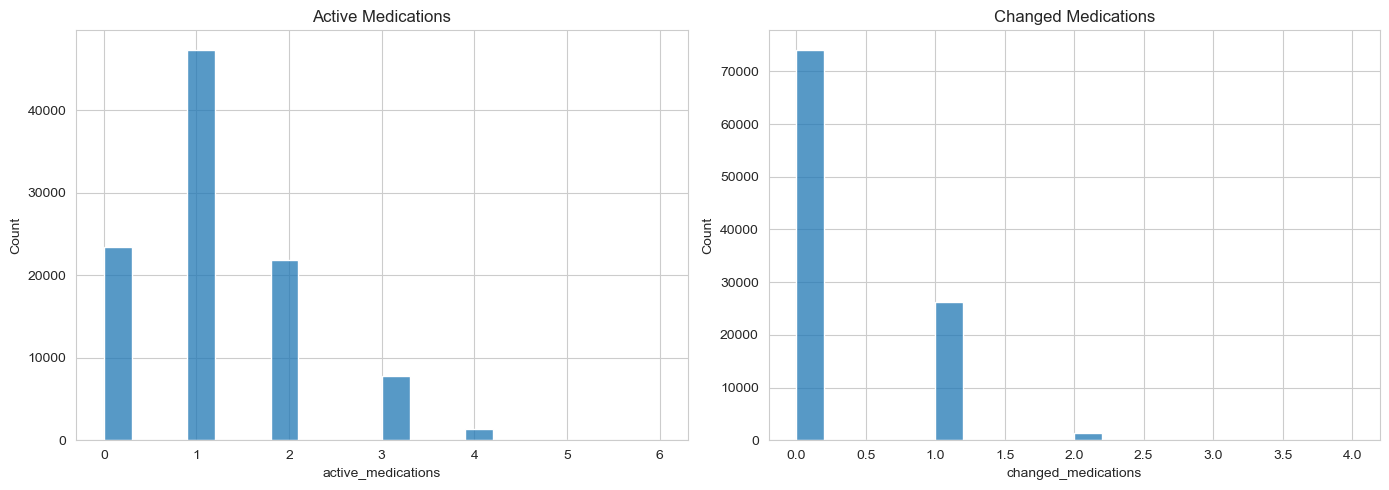

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    engineered_df["active_medications"],
    bins=20,
    ax=axes[0]
)

axes[0].set_title("Active Medications")

sns.histplot(
    engineered_df["changed_medications"],
    bins=20,
    ax=axes[1]
)

axes[1].set_title("Changed Medications")

plt.tight_layout()
plt.show()

## Relationship Between Total Visits and Target ##

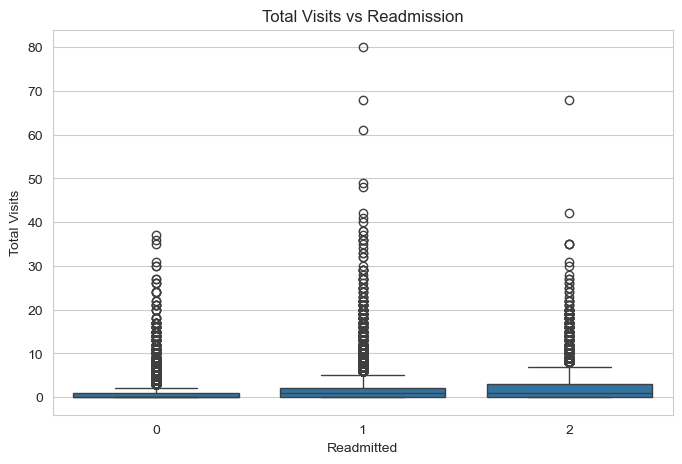

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=engineered_df,
    x="readmitted",
    y="total_visits"
)

plt.title("Total Visits vs Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Total Visits")

plt.show()

## Mean Comparison ##

In [18]:
engineered_df.groupby("readmitted")["total_visits"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)


,count,mean,median,std,min,max
readmitted,,,,,,
0,54864,0.764290,0.0,1.584722,0,37
1,35545,1.618990,1.0,2.698505,0,80
2,11357,2.018227,1.0,3.163241,0,68


## Active Medications vs Target ##

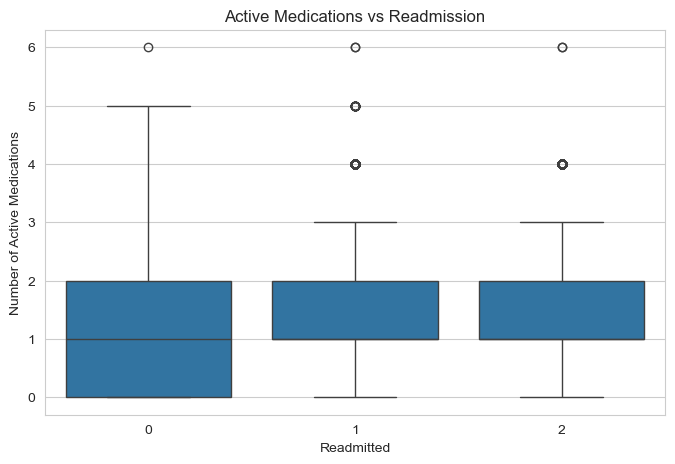

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=engineered_df,
    x="readmitted",
    y="active_medications"
)

plt.title("Active Medications vs Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Number of Active Medications")

plt.show()

## Statistics ##

In [20]:
engineered_df.groupby("readmitted")["active_medications"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
readmitted,,,,,,
0,54864,1.154418,1.0,0.938378,0,6
1,35545,1.215923,1.0,0.904321,0,6
2,11357,1.188518,1.0,0.875752,0,6


## Changed Medications vs Target ##

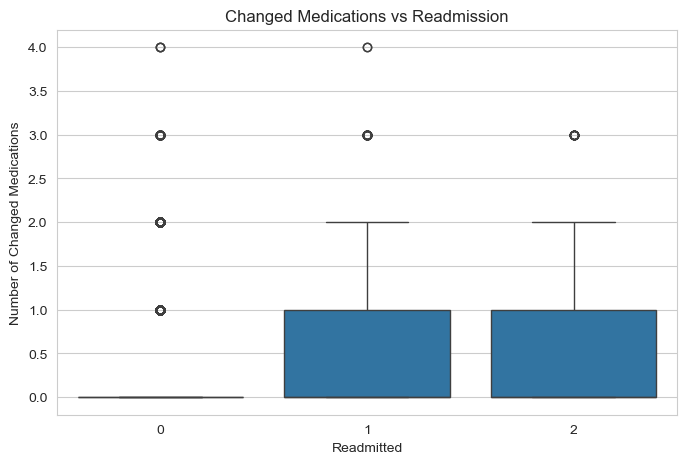

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=engineered_df,
    x="readmitted",
    y="changed_medications"
)

plt.title("Changed Medications vs Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Number of Changed Medications")

plt.show()

## Statistics ##

In [23]:
engineered_df.groupby("readmitted")["changed_medications"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
readmitted,,,,,,
0,54864,0.261264,0.0,0.473666,0,4
1,35545,0.312505,0.0,0.498893,0,4
2,11357,0.335476,0.0,0.509321,0,3


## Correlation with Numerical Features ##

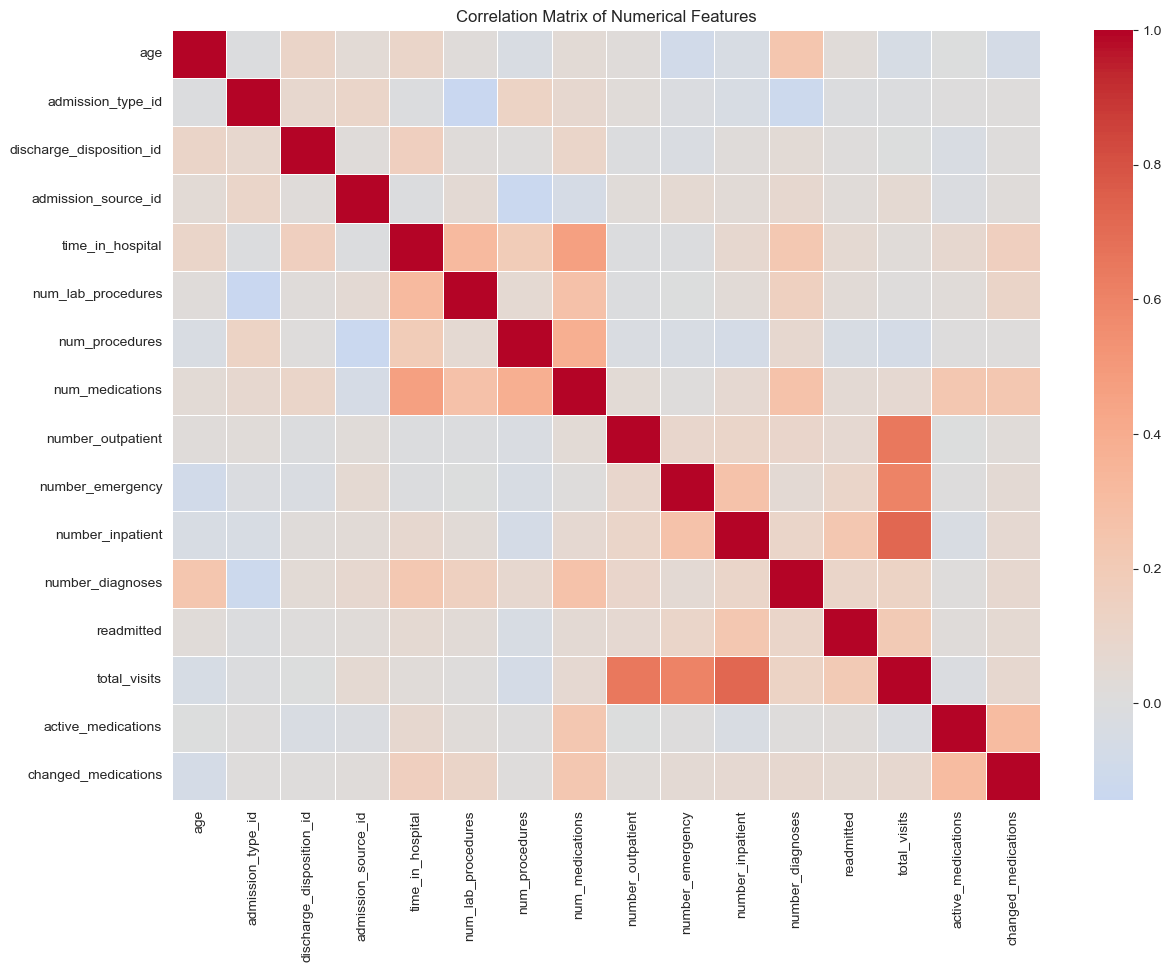

In [24]:
numeric_features = engineered_df.select_dtypes(include=["number"])

corr = numeric_features.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

## Save engineered dataset ## 

In [29]:
engineered_df.to_csv(
    "../data/processed/engineered_data.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.
